In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_files
from sklearn.linear_model import Lasso, Ridge, LogisticRegression
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_selection import RFE
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import os
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import mutual_info_classif
from sklearn.base import BaseEstimator, TransformerMixin
from warnings import filterwarnings
from sklearn.exceptions import ConvergenceWarning
filterwarnings('ignore', category=ConvergenceWarning)

# Load the dataset
Path_Images = 'cnd_large/images.csv'  # Update this path to your dataset
Path_Labels = 'cnd_large/labels.csv'  # Update this path to your labels if needed

images = pd.read_csv(Path_Images, sep=',', index_col=0)
labels = pd.read_csv(Path_Labels, sep=',', index_col=0)

labels = labels.rename(columns={"0": "label"})

#Size check of dataset
print(f"Number of images: {images.shape}")
print(f"Number of labels: {labels.shape}")

#Check number of unique labels
print(f"Unique labels: {labels["label"].unique()}")

#Number of cat images
cat_idx = np.where(labels == 0)[0]
print(f"Number of cat images: {cat_idx.size}")

# Make sure indices align
data = images.join(labels)

# Stratified sampling: keep 500 samples
subset, _ = train_test_split(
    data,
    train_size=2000,
    stratify=data['label'],
    random_state=42
)

# Split back into images and labels if needed
images_subset = subset.drop(columns=['label'])
labels_subset = subset[['label']]

cat_idx = np.where(labels_subset == 0)[0]
dog_idx = np.where(labels_subset == 1)[0]
print(f"Number of cat images in subset: {cat_idx.size}")
print(f"Number of cog images in subset: {dog_idx.size}")

Number of images: (10000, 4096)
Number of labels: (10000, 1)
Unique labels: [0 1]
Number of cat images: 5000
Number of cat images in subset: 1000
Number of cog images in subset: 1000


In [59]:
# Split train-test data
X_train, X_test, Y_train, Y_test = train_test_split(images_subset.values, labels_subset.values.ravel(), test_size=0.2, random_state=42)

print(f"Train X_data size: {X_train.shape}")
print(f"Train Y_data size: {Y_train.shape}")
print(f"Test X_data size: {X_test.shape}")

Train X_data size: (1600, 4096)
Train Y_data size: (1600,)
Test X_data size: (400, 4096)


In [16]:
def create_stratified_folds(X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True)
    folds = []
    for train_index, test_index in skf.split(X, y):
        folds.append((train_index, test_index))
    return folds

In [ ]:
#Lasso Selector
class LassoSelector(BaseEstimator, TransformerMixin):
    def __init__(self, alpha=0.01, threshold=0):
        self.alpha = alpha
        self.threshold = threshold
        self.mask_ = None
        
    def fit(self, X, y):
        lasso = Lasso(self.alpha)
        lasso.fit(X, y)
        self.mask_ = np.abs(lasso.coef_) > self.threshold
        return self
    
    def transform(self, X):
        return X[:, self.mask_]
    
    def get_support(self):
        return self.mask_

#Ridge selector
class RidgeSelector(BaseEstimator, TransformerMixin):
    def __init__(self, alpha=0.01, threshold=0, max_iter=1000):
        self.alpha = alpha
        self.threshold = threshold
        self.max_iter = max_iter
        self.mask_ = None

    def fit(self, X, y):
        ridge = Ridge(alpha=self.alpha, max_iter=self.max_iter)
        ridge.fit(X, y)
        self.mask_ = np.abs(ridge.coef_) > self.threshold
        return self

    def transform(self, X):
        return X[:, self.mask_]
    
    def get_support(self):
        return self.mask_

def run_pipeline(X_train, Y_train, X_test, Y_test, selector, classifiers, param_grids, filter_step_name, filter_score_func):
    """
    Runs GridSearchCV for each classifier using the given filter + selector.
    Returns a dict of {classifier_name: (grid_search, combined_mask)}
    """
    results = {}
    for clf_name, classifier in classifiers.items():
        param_grid = param_grids[clf_name]
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            (filter_step_name, SelectKBest(score_func=filter_score_func)),
            ('sel_selection', selector),
            ('classifier', classifier)
        ])

        grid_search = GridSearchCV(pipeline, param_grid, cv=4, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train, Y_train)

        y_pred = grid_search.predict(X_test)
        print(f"  [{clf_name}] Best params: {grid_search.best_params_}")
        print(f"  [{clf_name}] Best CV accuracy: {grid_search.best_score_:.4f}")
        print(f"  [{clf_name}] Test accuracy: {accuracy_score(Y_test, y_pred):.4f}")

        best_pipeline = grid_search.best_estimator_
        filter_mask = best_pipeline.named_steps[filter_step_name].get_support()
        sel_mask = best_pipeline.named_steps['sel_selection'].get_support()

        filter_indices = np.where(filter_mask)[0]
        combined_mask = np.zeros(X_train.shape[1], dtype=bool)
        combined_mask[filter_indices[sel_mask]] = True

        print(f"  [{clf_name}] Features after filter: {filter_mask.sum()}")
        print(f"  [{clf_name}] Features after selector: {sel_mask.sum()}")
        print(f"  [{clf_name}] Final features in original space: {combined_mask.sum()}")

        results[clf_name] = (grid_search, combined_mask)

    return results

def mi_inf(X_train, Y_train, X_test, Y_test, selector, classifiers, param_grids):
    print("--- Mutual Information ---")
    return run_pipeline(X_train, Y_train, X_test, Y_test, selector, classifiers, param_grids, 'mi_selection', mutual_info_classif)

def F_inf(X_train, Y_train, X_test, Y_test, selector, classifiers, param_grids):
    print("--- F-score ---")
    return run_pipeline(X_train, Y_train, X_test, Y_test, selector, classifiers, param_grids, 'f_selection', f_classif)

def get_combined_mask(pipeline, X_shape, first_step_name):
    first_mask = pipeline.named_steps[first_step_name].get_support()
    sel_mask = pipeline.named_steps['sel_selection'].get_support()
    first_indices = np.where(first_mask)[0]
    combined_mask = np.zeros(X_shape, dtype=bool)
    combined_mask[first_indices[sel_mask]] = True
    return combined_mask

In [78]:
knn_final = KNeighborsClassifier(n_neighbors=5, metric='euclidean', weights='distance')
logreg_final = LogisticRegression(C=0.01, max_iter=1000)
rf_final = RandomForestClassifier(n_estimators=100, random_state=42)

classifiers = {
    'knn': knn_final,
    'logreg': logreg_final,
    'rf': rf_final
}

# Param grids per classifier and method
param_grid_mi_lasso = {'mi_selection__k': [100, 250, 250], 'sel_selection__alpha': [0.0001, 0.001, 0.01]}
param_grid_mi_ridge = {'mi_selection__k': [100, 250, 250], 'sel_selection__alpha': [0.0001, 0.001, 0.01], 'sel_selection__threshold': [0.001, 0.01, 0.1]}
param_grid_f_lasso  = {'f_selection__k':  [100, 250, 250], 'sel_selection__alpha': [0.0001, 0.001, 0.01]}
param_grid_f_ridge  = {'f_selection__k':  [100, 250, 250], 'sel_selection__alpha': [0.0001, 0.001, 0.01], 'sel_selection__threshold': [0.001, 0.01, 0.1]}

# Same param grid for all classifiers
param_grids_mi_lasso = {clf: param_grid_mi_lasso for clf in classifiers.keys()}
param_grids_mi_ridge = {clf: param_grid_mi_ridge for clf in classifiers.keys()}
param_grids_f_lasso  = {clf: param_grid_f_lasso  for clf in classifiers.keys()}
param_grids_f_ridge  = {clf: param_grid_f_ridge  for clf in classifiers.keys()}

n = 5
# run_results now keyed by method + classifier
run_results = {
    f'{method}_{clf}': [] 
    for method in ['mi_lasso', 'mi_ridge', 'f_lasso', 'f_ridge'] 
    for clf in classifiers.keys()
}

for i in range(n):
    X_train, X_test, Y_train, Y_test = train_test_split(
        images_subset.values, labels_subset.values.ravel(), test_size=0.2, random_state=i
    )

    print(f"\n=== Run {i+1} ===")

    res_mi_lasso = mi_inf(X_train, Y_train, X_test, Y_test, LassoSelector(), classifiers, param_grids_mi_lasso)
    res_mi_ridge = mi_inf(X_train, Y_train, X_test, Y_test, RidgeSelector(), classifiers, param_grids_mi_ridge)
    res_f_lasso  = F_inf(X_train, Y_train, X_test, Y_test, LassoSelector(), classifiers, param_grids_f_lasso)
    res_f_ridge  = F_inf(X_train, Y_train, X_test, Y_test, RidgeSelector(), classifiers, param_grids_f_ridge)

    # Store results and build final pipelines
    final_pipelines = {}
    for clf_name, classifier in classifiers.items():
        for method, res, filter_name, filter_func, selector in [
            ('mi_lasso', res_mi_lasso, 'mi_selection', mutual_info_classif, LassoSelector()),
            ('mi_ridge', res_mi_ridge, 'mi_selection', mutual_info_classif, RidgeSelector()),
            ('f_lasso',  res_f_lasso,  'f_selection',  f_classif,           LassoSelector()),
            ('f_ridge',  res_f_ridge,  'f_selection',  f_classif,           RidgeSelector()),
        ]:
            key = f'{method}_{clf_name}'
            gs, _ = res[clf_name]

            print(f"\n--- {key} ---")
            print(f"Best params: {gs.best_params_}")
            print(f"Best CV accuracy: {gs.best_score_:.4f}")

            # Build final pipeline with best params from GridSearchCV
            selector_params = {k.replace('sel_selection__', ''): v for k, v in gs.best_params_.items() if 'sel_selection' in k}
            filter_k = gs.best_params_[f'{filter_name}__k']

            final_pipeline = Pipeline([
                ('scaler', StandardScaler()),
                (filter_name, SelectKBest(score_func=filter_func, k=filter_k)),
                ('sel_selection', selector.set_params(**selector_params)),
                ('classifier', classifier)
            ])

            final_pipeline.fit(X_train, Y_train)
            y_pred = final_pipeline.predict(X_test)
            acc = accuracy_score(Y_test, y_pred)
            print(f"Final test accuracy: {acc:.4f}")
            run_results[key].append(acc)
            final_pipelines[key] = final_pipeline

# Extract combined masks from last run
for key, pipeline in final_pipelines.items():
    filter_name = 'mi_selection' if 'mi' in key else 'f_selection'
    mask = get_combined_mask(pipeline, X_train.shape[1], filter_name)
    print(f"{key}: {mask.sum()} pixels selected")

# Boxplot
plt.figure(figsize=(16, 6))
plt.boxplot(run_results.values(), labels=run_results.keys(), xticks=range(1, len(run_results)+1))
plt.xticks(rotation=45, ha='right')
plt.title('Test Accuracy across Runs')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


=== Run 1 ===
--- Mutual Information ---
  [knn] Best params: {'mi_selection__k': 250, 'sel_selection__alpha': 0.01}
  [knn] Best CV accuracy: 0.7694
  [knn] Test accuracy: 0.7775
  [knn] Features after filter: 250
  [knn] Features after selector: 41
  [knn] Final features in original space: 41
  [logreg] Best params: {'mi_selection__k': 250, 'sel_selection__alpha': 0.0001}
  [logreg] Best CV accuracy: 0.7750
  [logreg] Test accuracy: 0.7600
  [logreg] Features after filter: 250
  [logreg] Features after selector: 239
  [logreg] Final features in original space: 239
  [rf] Best params: {'mi_selection__k': 250, 'sel_selection__alpha': 0.01}
  [rf] Best CV accuracy: 0.8088
  [rf] Test accuracy: 0.7925
  [rf] Features after filter: 250
  [rf] Features after selector: 41
  [rf] Final features in original space: 41
--- Mutual Information ---
  [knn] Best params: {'mi_selection__k': 250, 'sel_selection__alpha': 0.01, 'sel_selection__threshold': 0.01}
  [knn] Best CV accuracy: 0.7644
  [knn]

/var/folders/w6/12f9gy7j06z5nls9_8pzd71h0000gn/T/ipykernel_32147/2164988403.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(run_results.values(), labels=run_results.keys(), xticks=range(1, len(run_results)+1))


TypeError: boxplot() got an unexpected keyword argument 'xticks'

<Figure size 1600x600 with 0 Axes>

/var/folders/w6/12f9gy7j06z5nls9_8pzd71h0000gn/T/ipykernel_32147/3744806274.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(run_results.values(), labels=run_results.keys())


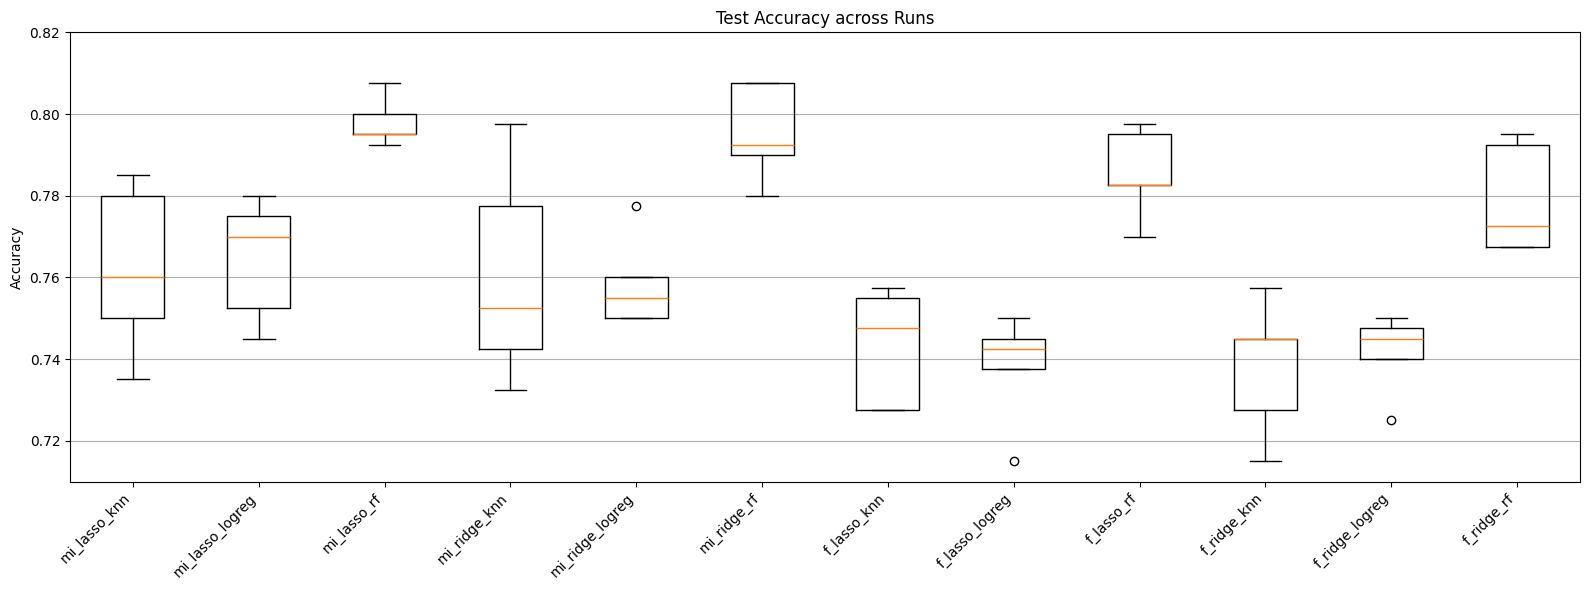

In [82]:
plt.figure(figsize=(16, 6))
plt.boxplot(run_results.values(), labels=run_results.keys())
plt.xticks(rotation=45, ha='right')
plt.title('Test Accuracy across Runs')
plt.ylabel('Accuracy')
plt.ylim(0.71, 0.82)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

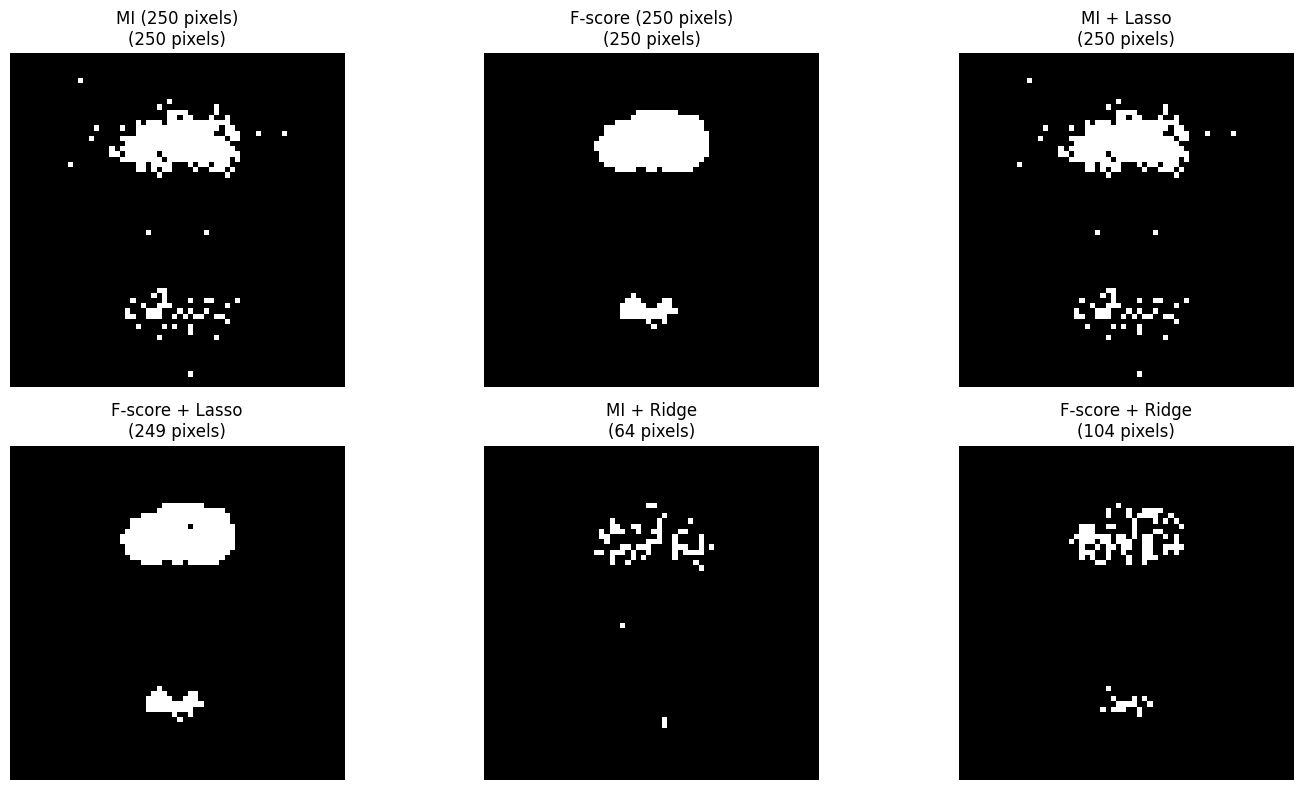

In [84]:
# Fit MI and F-score selectors
mi_selector = SelectKBest(score_func=mutual_info_classif, k=250)
mi_selector.fit(X_train, Y_train)
mi_mask = mi_selector.get_support()

f_selector = SelectKBest(score_func=f_classif, k=250)
f_selector.fit(X_train, Y_train)
f_mask = f_selector.get_support()

# Apply Lasso on MI-selected features
lasso = LassoSelector(alpha=0.001)
lasso.fit(X_train[:, mi_mask], Y_train)
lasso_mask_mi = np.zeros(X_train.shape[1], dtype=bool)
lasso_mask_mi[np.where(mi_mask)[0][lasso.get_support()]] = True

# Apply Ridge on MI-selected features
ridge = RidgeSelector(alpha=0.0001, threshold=0.001)
ridge.fit(X_train[:, mi_mask], Y_train)
ridge_mask_mi = np.zeros(X_train.shape[1], dtype=bool)
ridge_mask_mi[np.where(mi_mask)[0][ridge.get_support()]] = True

# Apply Lasso on F-score selected features
lasso_f = LassoSelector(alpha=0.001)
lasso_f.fit(X_train[:, f_mask], Y_train)
lasso_mask_f = np.zeros(X_train.shape[1], dtype=bool)
lasso_mask_f[np.where(f_mask)[0][lasso_f.get_support()]] = True

# Apply Ridge on F-score selected features
ridge_f = RidgeSelector(alpha=0.0001, threshold=0.001)
ridge_f.fit(X_train[:, f_mask], Y_train)
ridge_mask_f = np.zeros(X_train.shape[1], dtype=bool)
ridge_mask_f[np.where(f_mask)[0][ridge_f.get_support()]] = True

# Visualize all 6
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, mask, title in zip(axes.flatten(),
    [mi_mask, f_mask, lasso_mask_mi, lasso_mask_f, ridge_mask_mi, ridge_mask_f],
    ['MI (250 pixels)', 'F-score (250 pixels)',
     'MI + Lasso', 'F-score + Lasso',
     'MI + Ridge', 'F-score + Ridge']):
    image = np.zeros(X_train.shape[1])
    image[mask] = 255
    ax.imshow(image.reshape(64, 64), cmap='gray')
    ax.set_title(f"{title}\n({mask.sum()} pixels)")
    ax.axis('off')
plt.tight_layout()
plt.show()

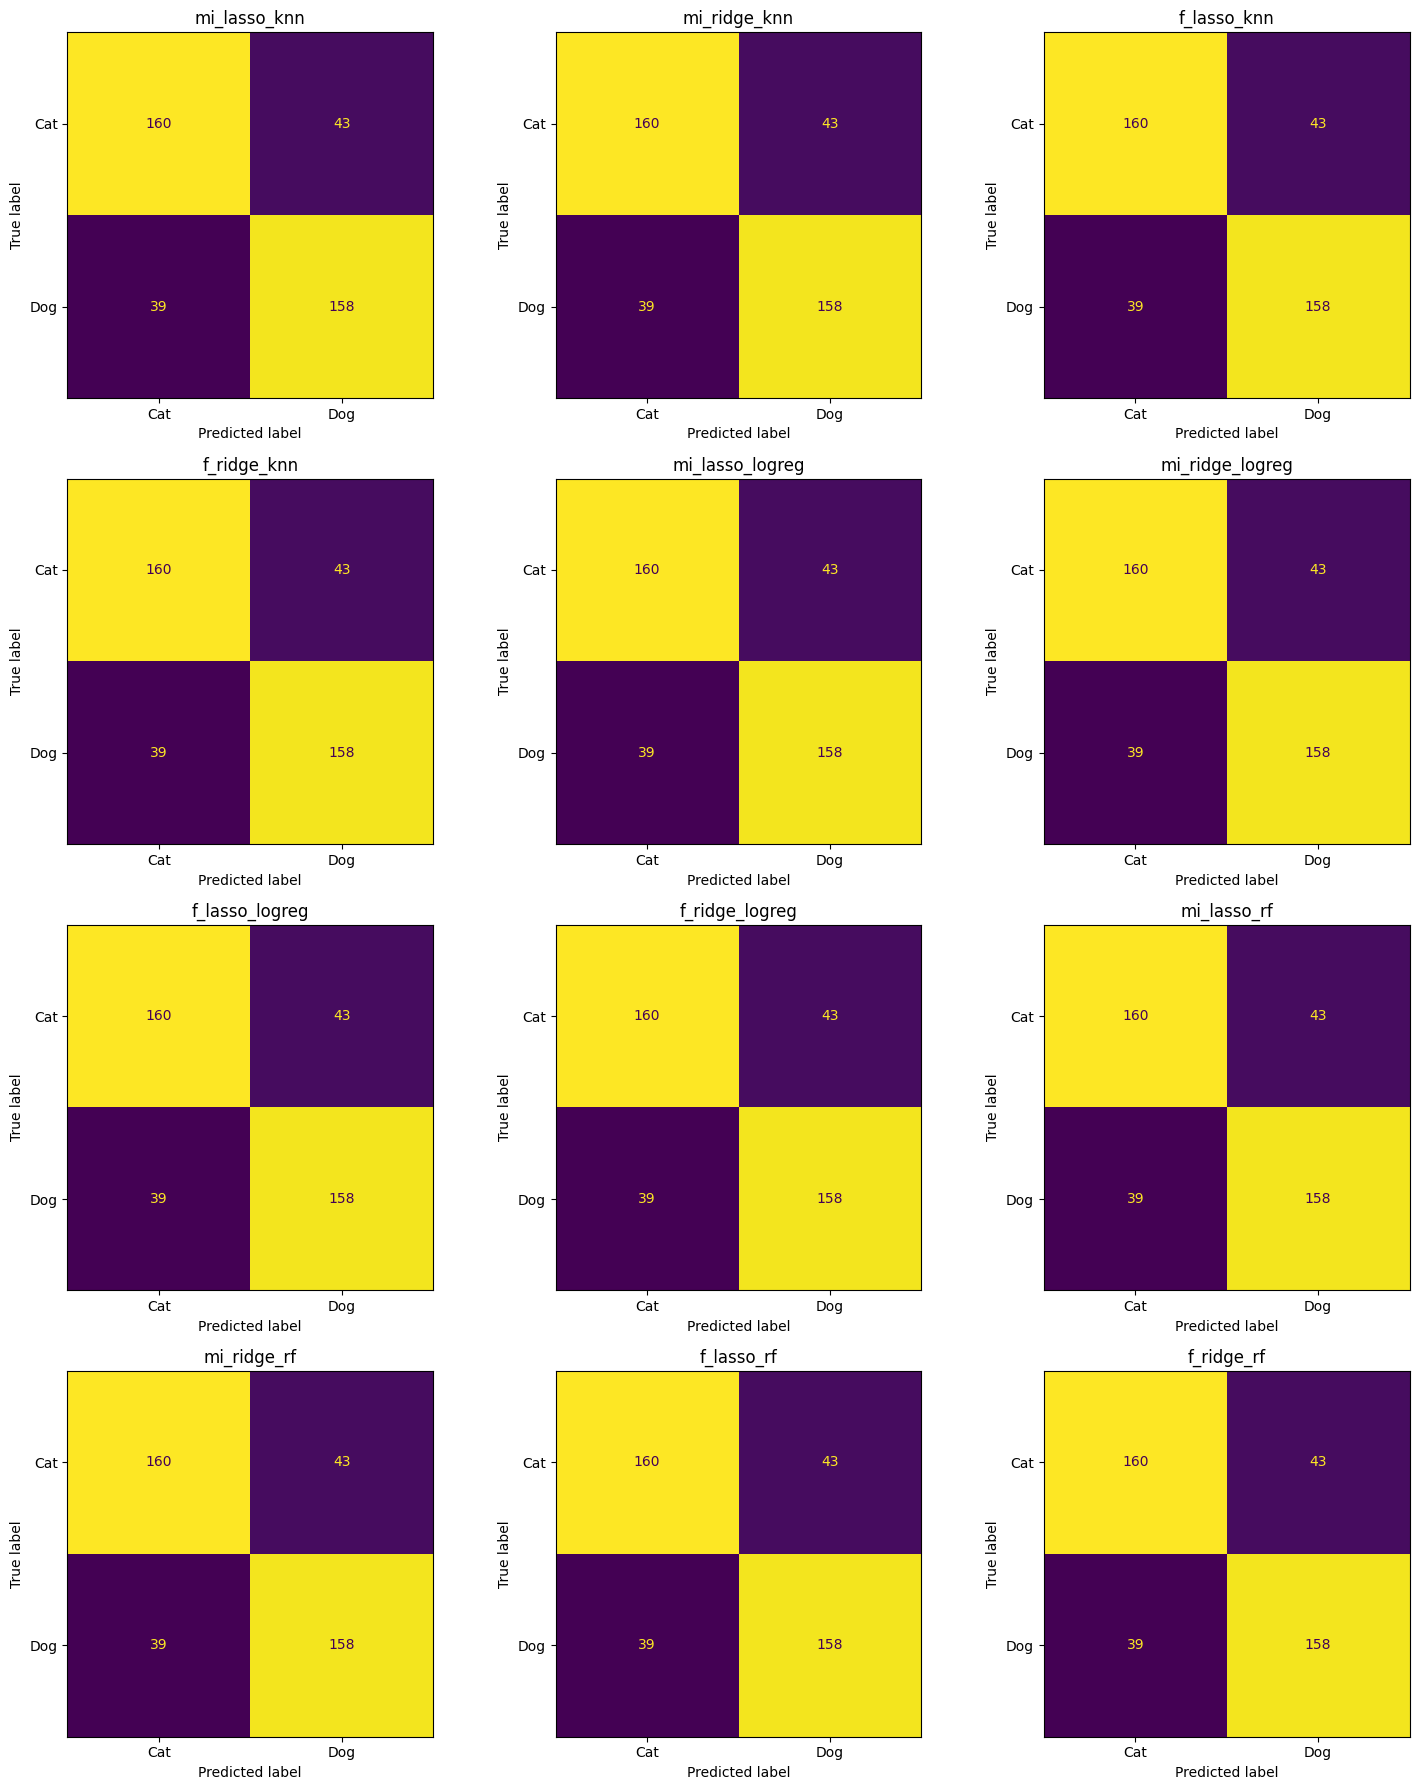

In [88]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(4, 3, figsize=(15, 18))
for ax, (key, pipeline) in zip(axes.flatten(), final_pipelines.items()):
    y_pred = final_pipeline.predict(X_test)
    cm = confusion_matrix(Y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Cat', 'Dog'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(key)
plt.tight_layout()
plt.show()